In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# Load the dataset
file_path = '../../data/Data3.csv'  # Make sure the file is in the same directory as the code
data = pd.read_csv(file_path)

In [3]:
# Create a 'Site' column with the first 7 letters of the 'ERBS' column
data['Site'] = data['ERBS'].str[:7]

# Group by 'Site' and 'STARTTIME_DATE', then average the values
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

C:\Users\HP\AppData\Local\Temp\ipykernel_78540\202914169.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()


In [4]:

# Normalize the target columns between 0 and 10
scaler = MinMaxScaler(feature_range=(0, 10))
columns_to_normalize = ['AVG_USR_THRPUT_DL', 'AVG_NO_USER', 'DL_TRAFFIC_MB']
grouped_data[columns_to_normalize] = scaler.fit_transform(grouped_data[columns_to_normalize])


In [5]:
# Function to create sequences for LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [6]:
# Prediction for a single target
def lstm_prediction(target_column):
    results = {}
    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        site_data = site_data.reshape(-1, 1)
        
        seq_length = 10
        X, y = create_sequences(site_data, seq_length)
        
        # Split data into train, test, validation
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        
        # LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_val, y_val), verbose=0)
        
        # Predictions and MSE calculation
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        val_pred = model.predict(X_val)
        
        train_mse = mean_squared_error(y_train, train_pred)
        test_mse = mean_squared_error(y_test, test_pred)
        val_mse = mean_squared_error(y_val, val_pred)
        
        results[site] = (train_mse, test_mse, val_mse)
    
    return results

In [8]:
def lstm_prediction(target_column):
    results = {}
    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        site_data = site_data.reshape(-1, 1)
        
        seq_length = 10
        if len(site_data) <= seq_length:
            print(f"Skipping site {site} due to insufficient data.")
            continue
        
        X, y = create_sequences(site_data, seq_length)
        
        # Split data into train, test, validation
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        if len(X_train) == 0 or len(X_test) == 0:
            print(f"Skipping site {site} because it results in empty train/test sets.")
            continue
        
        X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        
        # LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_val, y_val), verbose=0)
        
        # Predictions and MSE calculation
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        val_pred = model.predict(X_val)
        
        train_mse = mean_squared_error(y_train, train_pred)
        test_mse = mean_squared_error(y_test, test_pred)
        val_mse = mean_squared_error(y_val, val_pred)
        
        results[site] = (train_mse, test_mse, val_mse)
    
    return results

# Run the prediction for 'AVG_USR_THRPUT_DL'
avg_usr_thrput_dl_results = lstm_prediction('AVG_USR_THRPUT_DL')

# Get the best and worst 5 sites based on test MSE
sorted_results = sorted(avg_usr_thrput_dl_results.items(), key=lambda x: x[1][1])
best_5_sites = sorted_results[:5]
worst_5_sites = sorted_results[-5:]

1/1 [==============================] - 0s 16ms/step
Skipping site BMBNC54 due to insufficient data.
8/8 [==============================] - 1s 2ms/step


2/2 [==============================] - 0s 4ms/step


3/3 [==============================] - 0s 0s/step


2/2 [==============================] - 0s 16ms/step


In [9]:
print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

Best 5 Sites based on MSE: [('CXUKH39', (0.0018826037158564503, 0.0029601003500878014, 0.004971870457516221)), ('CXUKH38', (0.01185266169862632, 0.0030022833150283442, 0.03184162526141673)), ('CXUKH63', (0.007405725188931356, 0.0030440904808875773, 0.0125870909262108)), ('CXUKH62', (0.013406132968701402, 0.007444268550976225, 0.03976460995172458)), ('CGANW08', (0.017863271050406682, 0.00928569015321802, 0.012998384154708028))]
Worst 5 Sites based on MSE: [('BMBNC53', (0.3559615653342108, 0.6434147315337474, 0.5606791527430182)), ('BMKSB57', (0.7769072699750414, 0.7705371179539121, 1.5500925757656614)), ('CXUKH22', (0.78316438948338, 0.7978086558291245, 0.81964141285415)), ('CXUKH27', (1.2520673356847758, 0.8075400859931806, 1.4554130067659459)), ('BMKSB55', (0.860666956183636, 0.9874461732021527, 0.8281710479505245))]


In [10]:
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(site, X_test, y_test, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('AVG_USR_THRPUT_DL')
    plt.legend()
    plt.show()

In [14]:

def lstm_prediction_and_plot(target_column):
    results = {}
    degradation_count = 0
    increase_count = 0
    site_predictions = {}

    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        site_data = site_data.reshape(-1, 1)
        
        seq_length = 10
        if len(site_data) <= seq_length:
            print(f"Skipping site {site} due to insufficient data.")
            continue
        
        X, y = create_sequences(site_data, seq_length)
        
        # Split data into train, test, validation
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        if len(X_train) == 0 or len(X_test) == 0:
            print(f"Skipping site {site} because it results in empty train/test sets.")
            continue
        
        X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        
        # LSTM model
        model = Sequential()
        model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1))
        
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_val, y_val), verbose=0)
        
        # Predictions and MSE calculation
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        val_pred = model.predict(X_val)
        
        train_mse = mean_squared_error(y_train, train_pred)
        test_mse = mean_squared_error(y_test, test_pred)
        val_mse = mean_squared_error(y_val, val_pred)
        
        results[site] = (train_mse, test_mse, val_mse)
        site_predictions[site] = (X_test, y_test, test_pred)
        
        # Degradation and increase check
        degradation = ((y_test - test_pred) / y_test) >= 0.5
        increase = ((test_pred - y_test) / y_test) >= 0.001
        degradation_count += np.sum(degradation)
        increase_count += np.sum(increase)
    
    return results, site_predictions, degradation_count, increase_count

In [15]:
# Run the prediction for 'AVG_USR_THRPUT_DL'
avg_usr_thrput_dl_results, site_predictions, degradation_count, increase_count = lstm_prediction_and_plot('AVG_USR_THRPUT_DL')

# Get the best and worst 5 sites based on test MSE
sorted_results = sorted(avg_usr_thrput_dl_results.items(), key=lambda x: x[1][1])
best_5_sites = sorted_results[:5]
worst_5_sites = sorted_results[-5:]

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

1/1 [==============================] - 0s 31ms/step
Skipping site BMBNC54 due to insufficient data.
2/2 [==============================] - 0s 16ms/step


1/1 [==============================] - 0s 47ms/step


C:\Users\HP\AppData\Local\Temp\ipykernel_78540\3372773365.py:51: RuntimeWarning: divide by zero encountered in divide
  degradation = ((y_test - test_pred) / y_test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_78540\3372773365.py:52: RuntimeWarning: divide by zero encountered in divide
  increase = ((test_pred - y_test) / y_test) >= 0.001


3/3 [==============================] - 0s 0s/step


2/2 [==============================] - 0s 5ms/step


C:\Users\HP\AppData\Local\Temp\ipykernel_78540\3372773365.py:51: RuntimeWarning: divide by zero encountered in divide
  degradation = ((y_test - test_pred) / y_test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_78540\3372773365.py:52: RuntimeWarning: divide by zero encountered in divide
  increase = ((test_pred - y_test) / y_test) >= 0.001


2/2 [==============================] - 0s 10ms/step
Best 5 Sites based on MSE: [('CXUKH39', (0.0014976462083671977, 0.0023126564112685116, 0.003952190771184839)), ('CXUKH63', (0.008096667715377743, 0.0024590611808971785, 0.013462508299805397)), ('CXUKH38', (0.011805231657954413, 0.003520742102363696, 0.030742021540337176)), ('CXUKH62', (0.014438258866350343, 0.006976747961908094, 0.041517999825522074)), ('CGANW23', (0.010106587563725481, 0.009683407821337904, 0.01012155683970993))]
Worst 5 Sites based on MSE: [('CXUKH17', (0.4002567996291446, 0.4547676971847324, 0.4644019708560135)), ('CXUKH27', (1.2891962766506455, 0.8347463945263263, 1.447142794415097)), ('BMKSB57', (0.8242281848181858, 0.8420073677108806, 1.572944243404508)), ('CXUKH22', (0.8981712939063621, 0.8614736477618281, 0.8879641515928173)), ('BMKSB55', (0.8603214520853534, 0.9859974998263495, 0.8194795349724455))]


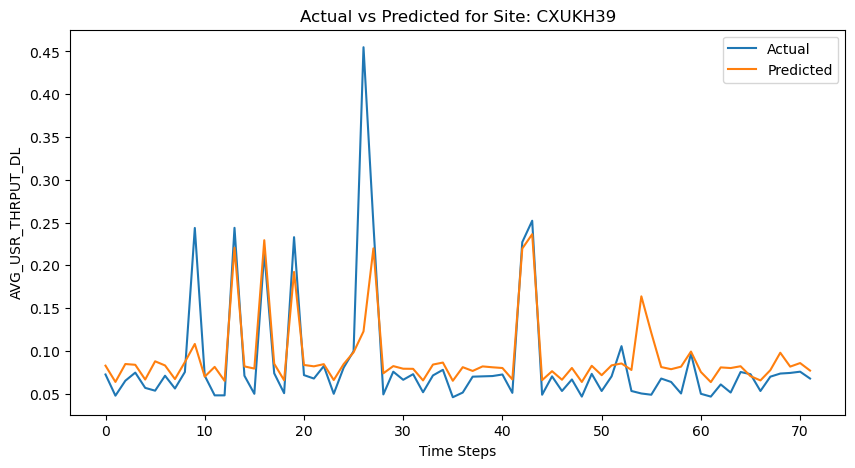

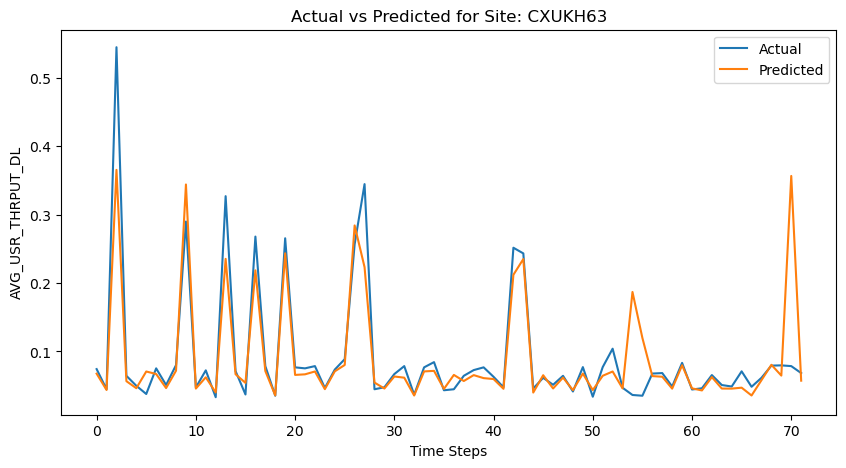

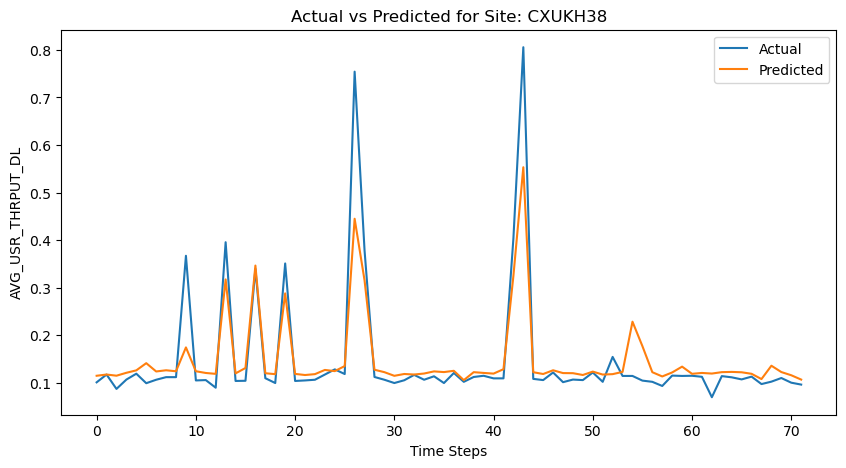

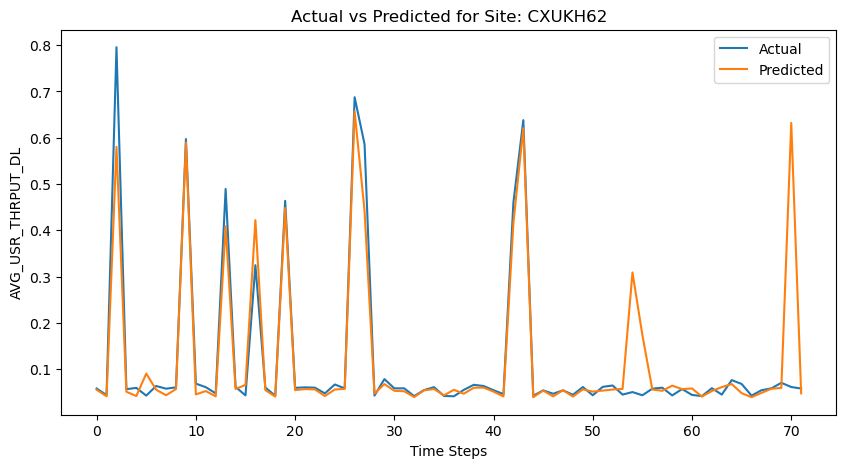

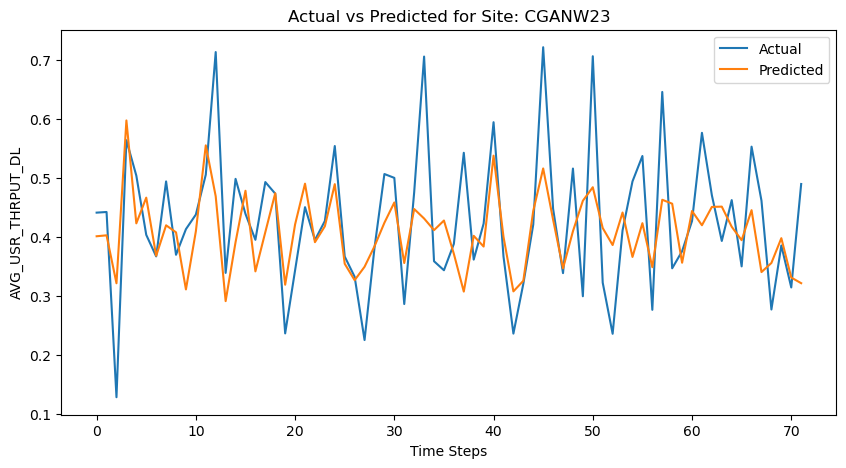

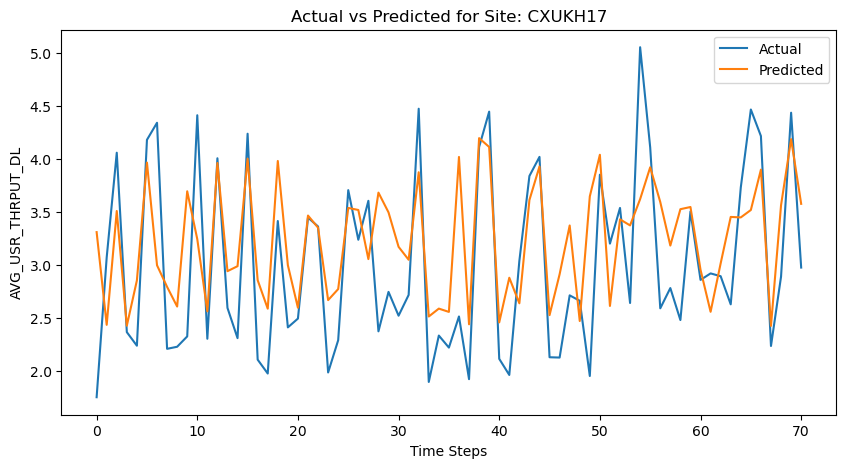

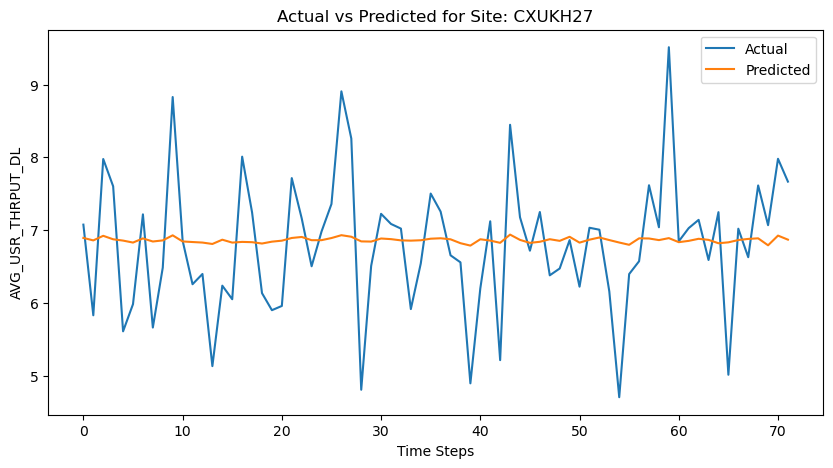

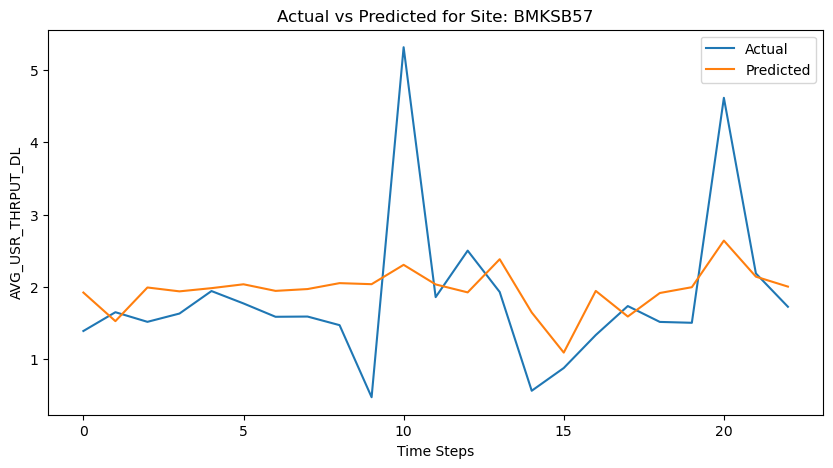

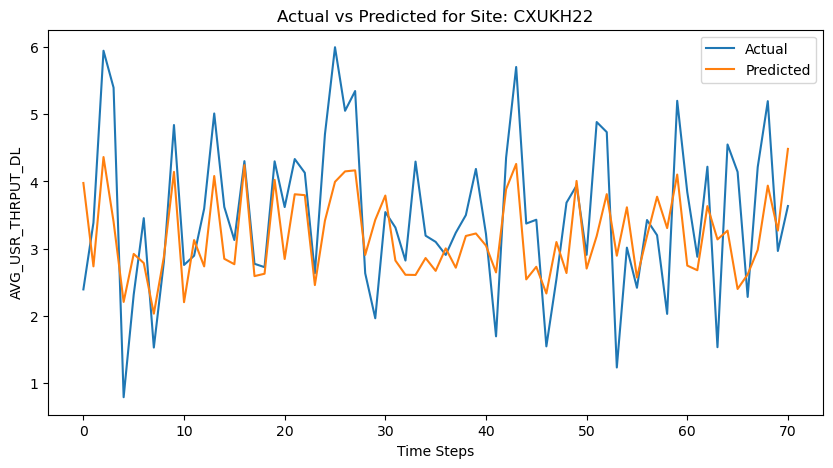

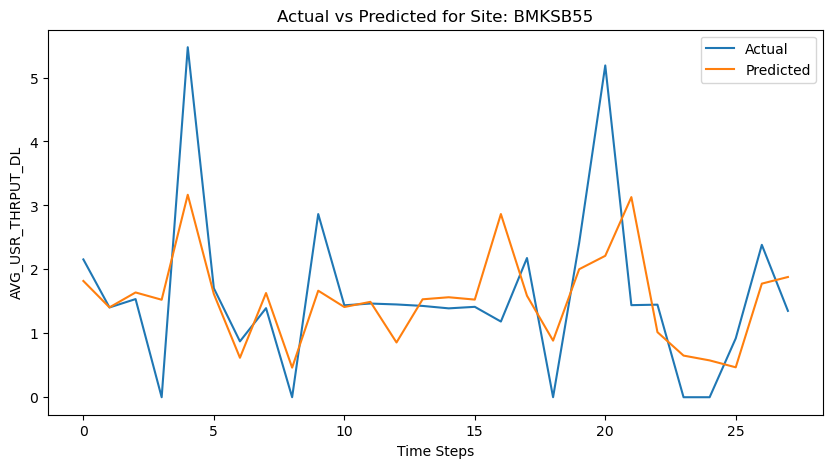

Number of cells with 50% or more degradation: 129
Number of cells with 0.1% or more increase: 6759


In [16]:
# Plot for the best and worst 5 sites
for site, _ in best_5_sites + worst_5_sites:
    X_test, y_test, y_pred = site_predictions[site]
    plot_actual_vs_predicted(site, X_test, y_test, y_pred)

# Print counts of degradation and increase
print(f"Number of cells with 50% or more degradation: {degradation_count}")
print(f"Number of cells with 0.1% or more increase: {increase_count}")

In [17]:
# Initialize counts
degraded_sites = set()
increased_sites = set()

# Check each site in the best and worst 5 sites
for site, _ in best_5_sites + worst_5_sites:
    _, y_test, y_pred = site_predictions[site]
    
    # Degradation: predicted value is 50% or more less than actual value
    degradation = ((y_test - y_pred) / y_test) >= 0.5
    if np.any(degradation):  # If any prediction for this site meets the degradation condition
        degraded_sites.add(site)
    
    # Increase: predicted value is at least 0.1% more than actual value
    increase = ((y_pred - y_test) / y_test) >= 0.001
    if np.any(increase):  # If any prediction for this site meets the increase condition
        increased_sites.add(site)

# Output the counts of unique sites
print(f"Number of unique Sites with 50% or more degradation: {len(degraded_sites)}")
print(f"Number of unique Sites with 0.1% or more increase: {len(increased_sites)}")

Number of unique Sites with 50% or more degradation: 4
Number of unique Sites with 0.1% or more increase: 10


C:\Users\HP\AppData\Local\Temp\ipykernel_78540\1602649607.py:10: RuntimeWarning: divide by zero encountered in divide
  degradation = ((y_test - y_pred) / y_test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_78540\1602649607.py:15: RuntimeWarning: divide by zero encountered in divide
  increase = ((y_pred - y_test) / y_test) >= 0.001


In [18]:
# Initialize counts
degraded_sites = set()
increased_sites = set()

# Check each site in the best and worst 5 sites
for site, _ in best_5_sites + worst_5_sites:
    _, y_test, y_pred = site_predictions[site]
    
    # Degradation: predicted value is 50% or more less than actual value
    degradation = ((y_test - y_pred) / y_test) >= 0.5
    if np.any(degradation):  # If any prediction for this site meets the degradation condition
        degraded_sites.add(site)
    
    # Increase: predicted value is at least 0.1% more than actual value
    increase = ((y_pred - y_test) / y_test) >= 0.001
    if np.any(increase):  # If any prediction for this site meets the increase condition
        increased_sites.add(site)

# Output the counts of unique sites
print(f"Number of unique Sites with 50% or more degradation: {len(degraded_sites)}")
print(f"Number of unique Sites with 0.1% or more increase: {len(increased_sites)}")

Number of unique Sites with 50% or more degradation: 4
Number of unique Sites with 0.1% or more increase: 10


C:\Users\HP\AppData\Local\Temp\ipykernel_78540\1602649607.py:10: RuntimeWarning: divide by zero encountered in divide
  degradation = ((y_test - y_pred) / y_test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_78540\1602649607.py:15: RuntimeWarning: divide by zero encountered in divide
  increase = ((y_pred - y_test) / y_test) >= 0.001


In [19]:
# Initialize sets to store the sites
degraded_sites = set()
increased_sites = set()

# Check each site in the best and worst 5 sites
for site, _ in best_5_sites + worst_5_sites:
    _, y_test, y_pred = site_predictions[site]
    
    # Degradation: predicted value is 50% or more less than actual value
    degradation = ((y_test - y_pred) / y_test) >= 0.5
    if np.any(degradation):  # If any prediction for this site meets the degradation condition
        degraded_sites.add(site)
    
    # Increase: predicted value is at least 0.1% more than actual value
    increase = ((y_pred - y_test) / y_test) >= 0.001
    if np.any(increase):  # If any prediction for this site meets the increase condition
        increased_sites.add(site)

# Convert sets to lists for easy viewing
degraded_sites_list = list(degraded_sites)
increased_sites_list = list(increased_sites)

# Output the counts and lists
print(f"Number of unique Sites with 50% or more degradation: {len(degraded_sites_list)}")
print(f"Sites with 50% or more degradation: {degraded_sites_list}")

print(f"Number of unique Sites with 0.1% or more increase: {len(increased_sites_list)}")
print(f"Sites with 0.1% or more increase: {increased_sites_list}")

Number of unique Sites with 50% or more degradation: 4
Sites with 50% or more degradation: ['CXUKH38', 'BMKSB57', 'BMKSB55', 'CXUKH39']
Number of unique Sites with 0.1% or more increase: 10
Sites with 0.1% or more increase: ['CXUKH17', 'CGANW23', 'CXUKH38', 'CXUKH27', 'CXUKH63', 'BMKSB57', 'BMKSB55', 'CXUKH39', 'CXUKH62', 'CXUKH22']


C:\Users\HP\AppData\Local\Temp\ipykernel_78540\2284944244.py:10: RuntimeWarning: divide by zero encountered in divide
  degradation = ((y_test - y_pred) / y_test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_78540\2284944244.py:15: RuntimeWarning: divide by zero encountered in divide
  increase = ((y_pred - y_test) / y_test) >= 0.001


In [20]:
# Initialize sets to store the sites
degraded_sites = set()
increased_sites = set()

# Check each site in the best and worst 5 sites
for site, _ in best_5_sites + worst_5_sites:
    _, y_test, y_pred = site_predictions[site]
    
    # Degradation: predicted value is 50% or more less than actual value
    degradation = ((y_test - y_pred) / y_test) >= 0.5
    if np.any(degradation):  # If any prediction for this site meets the degradation condition
        degraded_sites.add(site)
    
    # Increase: predicted value is at least 0.1% more than actual value
    increase = ((y_pred - y_test) / y_test) >= 0.001
    if np.any(increase):  # If any prediction for this site meets the increase condition
        increased_sites.add(site)

# Combine the two sets to get the total unique site count
all_affected_sites = degraded_sites.union(increased_sites)

# Convert sets to lists for easy viewing
degraded_sites_list = list(degraded_sites)
increased_sites_list = list(increased_sites)
all_affected_sites_list = list(all_affected_sites)

# Output the counts and lists
print(f"Number of unique Sites with 50% or more degradation: {len(degraded_sites_list)}")
print(f"Sites with 50% or more degradation: {degraded_sites_list}")

print(f"Number of unique Sites with 0.1% or more increase: {len(increased_sites_list)}")
print(f"Sites with 0.1% or more increase: {increased_sites_list}")

print(f"Total number of unique Sites affected (either degradation or increase): {len(all_affected_sites_list)}")
print(f"Total affected Sites: {all_affected_sites_list}")

Number of unique Sites with 50% or more degradation: 4
Sites with 50% or more degradation: ['CXUKH38', 'BMKSB57', 'BMKSB55', 'CXUKH39']
Number of unique Sites with 0.1% or more increase: 10
Sites with 0.1% or more increase: ['CXUKH17', 'CGANW23', 'CXUKH38', 'CXUKH27', 'CXUKH63', 'BMKSB57', 'BMKSB55', 'CXUKH39', 'CXUKH62', 'CXUKH22']
Total number of unique Sites affected (either degradation or increase): 10
Total affected Sites: ['CXUKH17', 'CGANW23', 'CXUKH38', 'CXUKH27', 'CXUKH63', 'BMKSB57', 'CXUKH62', 'CXUKH39', 'BMKSB55', 'CXUKH22']


C:\Users\HP\AppData\Local\Temp\ipykernel_78540\3215764222.py:10: RuntimeWarning: divide by zero encountered in divide
  degradation = ((y_test - y_pred) / y_test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_78540\3215764222.py:15: RuntimeWarning: divide by zero encountered in divide
  increase = ((y_pred - y_test) / y_test) >= 0.001


NameError: name 'model' is not defined